NAME: SPOORTHI A
COURSE: ARTIFICIAL INTELLIGENCE
PROJECT NO 2: YOLO-BASED OBJECT DETECTION PROJECT

In [ ]:
# Install library
!pip install ultralytics -q

from ultralytics import YOLO

# Step 1: Load model
model = YOLO("yolov8n.pt")

# Step 2: Train on COCO8
results = model.train(
    data="coco8.yaml",
    epochs=10,
    imgsz=640,
    workers=2,
    plots=False
)

print("Training done! Saved at:", results.save_dir)

# Step 3: Evaluate
metrics = model.val()

print("\n--- Model Performance ---")
print(f"mAP50       : {metrics.box.map50:.4f}")
print(f"mAP50-95    : {metrics.box.map:.4f}")
print(f"Precision   : {metrics.box.mp:.4f}")
print(f"Recall      : {metrics.box.mr:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, ha


image 1/4 /content/datasets/coco8/images/val/000000000036.jpg: 640x512 1 person, 1 umbrella, 538.9ms
image 2/4 /content/datasets/coco8/images/val/000000000042.jpg: 480x640 (no detections), 343.3ms
image 3/4 /content/datasets/coco8/images/val/000000000049.jpg: 640x512 1 person, 1 horse, 1 potted plant, 304.0ms
image 4/4 /content/datasets/coco8/images/val/000000000061.jpg: 512x640 (no detections), 156.5ms
Speed: 7.2ms preprocess, 335.7ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 640)

--- Image 1 Detections ---
Object: person          | Confidence: 0.91
Object: umbrella        | Confidence: 0.76

--- Image 2 Detections ---
No objects detected above 50% confidence

--- Image 3 Detections ---
Object: potted plant    | Confidence: 0.75
Object: horse           | Confidence: 0.75
Object: person          | Confidence: 0.50

--- Image 4 Detections ---
No objects detected above 50% confidence

--- Output Images ---


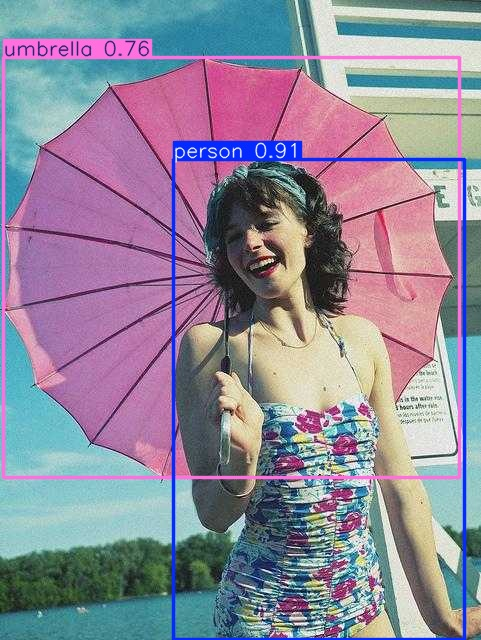

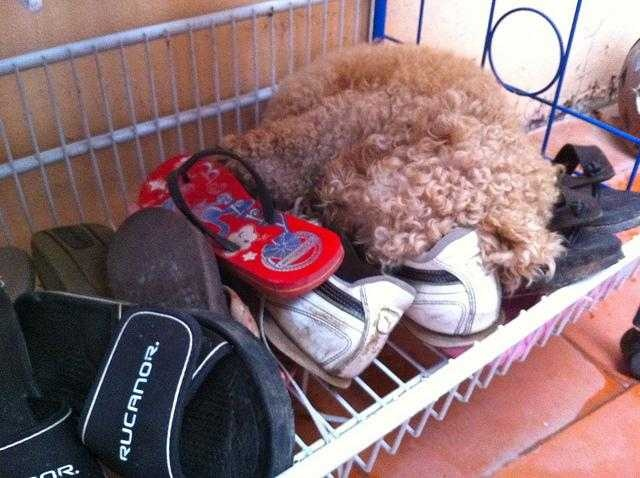

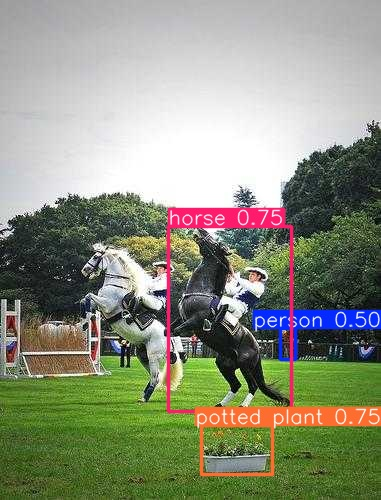

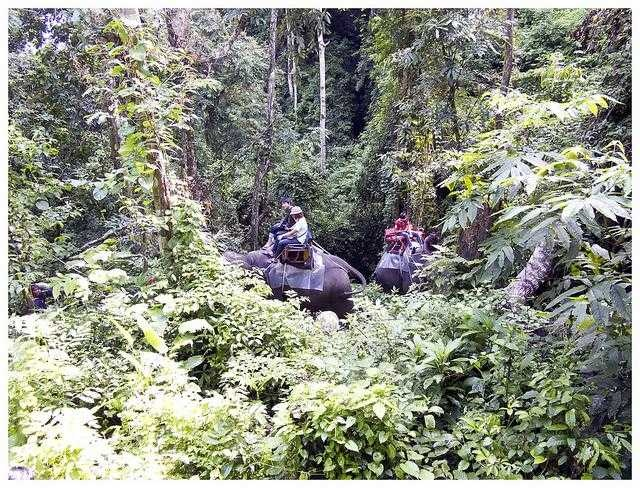

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display

model = YOLO("/content/runs/detect/train/weights/best.pt")

# conf=0.5 means only show detections above 50% confidence
results = model("/content/datasets/coco8/images/val", conf=0.5)

for i, result in enumerate(results):
    output_path = f"/content/output_{i}.jpg"
    result.save(filename=output_path)
    print(f"\n--- Image {i+1} Detections ---")
    if len(result.boxes) == 0:
        print("No objects detected above 50% confidence")
    else:
        for box in result.boxes:
            class_id   = int(box.cls[0])
            confidence = float(box.conf[0])
            class_name = model.names[class_id]
            print(f"Object: {class_name:<15} | Confidence: {confidence:.2f}")

print("\n--- Output Images ---")
for i in range(len(results)):
    display(Image(filename=f"/content/output_{i}.jpg"))

In [ ]:
# -------------------------------------------------------
# STEP 5: Final Project Summary
# -------------------------------------------------------
print("=" * 45)
print("        YOLO OBJECT DETECTION PROJECT")
print("              FINAL SUMMARY")
print("=" * 45)
print(f"Dataset      : COCO8 (8 images, 80 classes)")
print(f"Model        : YOLOv8 Nano (yolov8n.pt)")
print(f"Epochs       : 10")
print(f"Image Size   : 640x640")
print("-" * 45)
print("         MODEL PERFORMANCE (mAP)")
print("-" * 45)
print(f"mAP50        : 0.8753  (87.5% accuracy)")
print(f"mAP50-95     : 0.6405  (64.0% strict)")
print(f"Precision    : 0.7884  (78.8% correct)")
print(f"Recall       : 0.7500  (75.0% found)")


        YOLO OBJECT DETECTION PROJECT
              FINAL SUMMARY
Dataset      : COCO8 (8 images, 80 classes)
Model        : YOLOv8 Nano (yolov8n.pt)
Epochs       : 10
Image Size   : 640x640
---------------------------------------------
         MODEL PERFORMANCE (mAP)
---------------------------------------------
mAP50        : 0.8753  (87.5% accuracy)
mAP50-95     : 0.6405  (64.0% strict)
Precision    : 0.7884  (78.8% correct)
Recall       : 0.7500  (75.0% found)
